# Aim 1 - Top-5 gene determination + between-group descriptive comparison

Final reflection of:
- README Section 7 (Aim 1 spec)
- `src/modeling/aim1_gene_pathway.py` (2x2 Fisher per top-5 gene + Sanchez-Vega pathway, Holm/BH correction, forest, oncoprint)
- `src/modeling/_lib.py` (shared `load_cohort`, `load_top_genes`, `ensure_dirs`, `prep_covariates`)
- `src/data reports/export and generate genetic mut prevalence plots.py` (top genes + per-subtype prevalence grid)
- `~/Documents/GitHub/plots_descriptive.R` (retargeted from DFS to `any_brain_met`)
- `~/Documents/GitHub/genie_scripts_xgb_aft/descriptive_dfs_analysis.py`, `generate_characteristics_and_plots.py`, `gene_mutation_assessment.py`

**Cohorts.** Top-5 derivation cohort: `any_brain_met == 1`, n = 393 samples / 362 patients. Between-group comparison: full frame, n = 1,234 samples.

**Top-5 list (verified against `extracted_variables_genie_top_genes.txt`):** TP53, PIK3CA, GATA3, CDH1, PTEN.

## 0. Setup

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

PROJ = Path('/Users/robertjames/Documents/Documents - Robert\u2019s iMac/Research Projects/MSKCC Research Fellowship/Projects/genie_tcga_impact_brain_mets')
PROC = PROJ / 'data/processed'
FIG  = PROJ / 'manuscript components' / 'figures' / 'aim1'
OUT  = PROJ / 'data/interim' / 'aim1'
MOD  = PROJ / 'src/modeling/genie/aim1'
for p in (FIG, OUT, MOD): p.mkdir(parents=True, exist_ok=True)

# Re-use the project's shared modeling lib
sys.path.insert(0, str(PROJ / 'src/modeling'))
import _lib as L

sns.set_context('notebook')
plt.rcParams['figure.dpi'] = 110

COHORT = 'genie'
PATHWAY_COLS = L.PATHWAY_COLS
print('PATHWAY_COLS:', PATHWAY_COLS)

PATHWAY_COLS: ['pathway_RTK/RAS', 'pathway_Nrf2', 'pathway_PI3K', 'pathway_TGFB', 'pathway_p53', 'pathway_Wnt', 'pathway_Myc', 'pathway_Cell cycle', 'pathway_Hippo', 'pathway_Notch']


In [2]:
df = L.load_cohort(COHORT)
top5 = L.load_top_genes(COHORT, n=5)
top10 = L.load_top_genes(COHORT, n=10)
print(f'Cohort: {COHORT}  |  shape: {df.shape}  |  patients: {df["record_id"].nunique()}')
print(f'Top-5 (from disk): {top5}')
print(f'Top-10 (from disk): {top10}')

Cohort: genie  |  shape: (1234, 2108)  |  patients: 1130
Top-5 (from disk): ['TP53', 'PIK3CA', 'GATA3', 'CDH1', 'PTEN']
Top-10 (from disk): ['TP53', 'PIK3CA', 'GATA3', 'CDH1', 'PTEN', 'NF1', 'ARID1A', 'KMT2D', 'BRCA2', 'KMT2C']


## 1. Cohort flow with step-by-step intersection diagnostics

Per README Section 4. Print every intersection that defines an aim cohort so sizes are auditable.

In [3]:
rows = []
rows.append(('Full frame', len(df), df['record_id'].nunique()))
rows.append(('any_brain_met == 1 (Aim 1 top-5 cohort + Aim 3 cohort)',
             int((df['any_brain_met']==1).sum()),
             df.loc[df['any_brain_met']==1, 'record_id'].nunique()))
rows.append(('brain_met_at_dx == 1', int((df['brain_met_at_dx']==1).sum()),
             df.loc[df['brain_met_at_dx']==1, 'record_id'].nunique()))
rows.append(('brain_met_at_dx == 0 (Aim 2 cohort)',
             int((df['brain_met_at_dx']==0).sum()),
             df.loc[df['brain_met_at_dx']==0, 'record_id'].nunique()))
rows.append(('Stage I-III at dx', int((df['stage_iv_bin']==0).sum()),
             df.loc[df['stage_iv_bin']==0, 'record_id'].nunique()))
rows.append(('Stage IV at dx, non-CNS site', int(((df['stage_iv_bin']==1) & (df['brain_met_at_dx']==0)).sum()),
             df.loc[((df['stage_iv_bin']==1) & (df['brain_met_at_dx']==0)), 'record_id'].nunique()))
cohort_df = pd.DataFrame(rows, columns=['cohort', 'n_samples', 'n_patients'])
cohort_df.to_csv(OUT / 'aim1_cohort_sizes.csv', index=False)
cohort_df

,cohort,n_samples,n_patients
0,Full frame,1234,1130
1,any_brain_met == 1 (Aim 1 top-5 cohort + Aim 3...,393,362
2,brain_met_at_dx == 1,9,9
3,brain_met_at_dx == 0 (Aim 2 cohort),1225,1121
4,Stage I-III at dx,970,890
5,"Stage IV at dx, non-CNS site",255,231


## 2. Top-5 gene determination (verification)

Per Section 7: restrict to `any_brain_met == 1`, count mutated samples per gene, take top 5. The frame already has `top5_any_mutated` / `top5_n_mutated` / `G_top10_<GENE>` derived; we cross-check against a fresh re-ranking and against `extracted_variables_genie_gene_prev_brain_met.csv`.

In [4]:
# Canonical prevalence ranking from disk
prev = pd.read_csv(PROC / 'extracted_variables_genie_gene_prev_brain_met.csv')
print('Top-10 from disk (canonical):')
print(prev.head(10).to_string(index=False))

# Fresh re-ranking from gene-binary cols
brain = df[df['any_brain_met']==1]
candidate_mut_cols = [c for c in df.columns
                     if c == c.upper() and not c.endswith(('.Amp','.Del','.fus'))
                     and pd.api.types.is_integer_dtype(df[c])
                     and set(df[c].dropna().unique()).issubset({0,1})]
exclude = {'ETHNICITY','SEX','CENTER','SAMPLE_ID','PATIENT_ID','CANCER_TYPE',
           'CANCER_TYPE_DETAILED','ONCOTREE_CODE','SAMPLE_TYPE','SAMPLE_TYPE_DETAILED',
           'PRIMARY_RACE','SEQ_ASSAY_ID','DMETS_DX_BRAIN'}
candidate_mut_cols = [c for c in candidate_mut_cols if c not in exclude]
rank_live = (brain[candidate_mut_cols].sum().sort_values(ascending=False).head(15)
                 .to_frame('n_mut_brain_met'))
rank_live['pct'] = rank_live['n_mut_brain_met'] / len(brain)
print('\nFresh top-15 re-ranking:')
print(rank_live.head(15))

Top-10 from disk (canonical):
  gene  n_brain_met_samples_mutated  pct_brain_met  n_total_samples_mutated  pct_total
  TP53                          206       0.524173                      570   0.461912
PIK3CA                          112       0.284987                      353   0.286062
 GATA3                           46       0.117048                      174   0.141005
  CDH1                           35       0.089059                      122   0.098865
  PTEN                           26       0.066158                       73   0.059157
   NF1                           25       0.063613                       63   0.051053
ARID1A                           24       0.061069                       84   0.068071
 KMT2D                           24       0.061069                       78   0.063209
 BRCA2                           24       0.061069                       66   0.053485
 KMT2C                           23       0.058524                       61   0.049433

Fresh top-15

## 3. Between-group prevalence comparison (Section 7)

Lift the function out of `src/modeling/aim1_gene_pathway.py` so the notebook computes the *same* 2x2 -> Fisher -> Holm/BH pipeline.

In [5]:
def two_by_two(df, gene_col, group_col='any_brain_met'):
    """From src/modeling/aim1_gene_pathway.py:two_by_two."""
    sub = df[[gene_col, group_col]].dropna()
    sub = sub[sub[gene_col].isin([0,1]) & sub[group_col].isin([0,1])]
    a = int(((sub[group_col]==1) & (sub[gene_col]==1)).sum())
    b = int(((sub[group_col]==1) & (sub[gene_col]==0)).sum())
    c = int(((sub[group_col]==0) & (sub[gene_col]==1)).sum())
    d = int(((sub[group_col]==0) & (sub[gene_col]==0)).sum())
    p1 = a/(a+b) if (a+b)>0 else np.nan
    p0 = c/(c+d) if (c+d)>0 else np.nan
    if a>0 and c>0:
        log_pr = np.log(p1/p0)
        se = np.sqrt(1/a - 1/(a+b) + 1/c - 1/(c+d))
        pr, lo, hi = float(np.exp(log_pr)), float(np.exp(log_pr-1.96*se)), float(np.exp(log_pr+1.96*se))
    else:
        pr, lo, hi = np.nan, np.nan, np.nan
    try:
        _, pval = fisher_exact([[a,b],[c,d]])
    except Exception:
        pval = np.nan
    return dict(feature=gene_col, n_brain_met=a+b, n_no_brain_met=c+d,
                count_brain_met_mut=a, count_no_brain_met_mut=c,
                prev_brain_met=p1, prev_no_brain_met=p0,
                prev_ratio=pr, pr_lo=lo, pr_hi=hi, fisher_p=pval)

# Top-5 genes
gene_rows = [dict(kind='gene', **two_by_two(df, g)) for g in top5 if g in df.columns]
# Pathways
path_present = [p for p in PATHWAY_COLS if p in df.columns]
path_rows = [dict(kind='pathway', **two_by_two(df, p)) for p in path_present]
res = pd.DataFrame(gene_rows + path_rows)

# Multiple-testing correction WITHIN kind (5 gene tests; 10 pathway tests)
for k in res['kind'].unique():
    mask = res['kind']==k
    ps = res.loc[mask,'fisher_p'].fillna(1.0).values
    res.loc[mask, 'p_holm'] = multipletests(ps, method='holm')[1]
    res.loc[mask, 'p_bh']   = multipletests(ps, method='fdr_bh')[1]

out_csv = OUT / 'aim1_gene_pathway_comparison.csv'
res.to_csv(out_csv, index=False)
print(f'wrote {out_csv}')
res

wrote /Users/robertjames/Documents/Documents - Robert’s iMac/Research Projects/MSKCC Research Fellowship/Projects/genie_tcga_impact_brain_mets/data/interim/aim1/aim1_gene_pathway_comparison.csv


,kind,feature,n_brain_met,n_no_brain_met,count_brain_met_mut,count_no_brain_met_mut,prev_brain_met,prev_no_brain_met,prev_ratio,pr_lo,pr_hi,fisher_p,p_holm,p_bh
0,gene,TP53,393,841,206,364,0.524173,0.432818,1.211070,1.072085,1.368074,0.003241,0.016204,0.016204
1,gene,PIK3CA,393,841,112,241,0.284987,0.286564,0.994499,0.822850,1.201955,1.000000,1.000000,1.000000
2,gene,GATA3,393,841,46,128,0.117048,0.152200,0.769044,0.561278,1.053719,0.113837,0.455347,0.284592
3,gene,CDH1,393,841,35,87,0.089059,0.103448,0.860899,0.592518,1.250842,0.474336,1.000000,0.646857
4,gene,PTEN,393,841,26,47,0.066158,0.055886,1.183802,0.744451,1.882443,0.517486,1.000000,0.646857
5,pathway,pathway_RTK/RAS,393,841,248,448,0.631043,0.532699,1.184615,1.073383,1.307373,0.001342,0.013419,0.013419
6,pathway,pathway_Nrf2,393,841,11,24,0.027990,0.028537,0.980810,0.485338,1.982101,1.000000,1.000000,1.000000
7,pathway,pathway_PI3K,393,841,197,420,0.501272,0.499405,1.003738,0.890592,1.131259,1.000000,1.000000,1.000000
8,pathway,pathway_TGFB,393,841,14,19,0.035623,0.022592,1.576805,0.798926,3.112068,0.189367,0.946835,0.315612
9,pathway,pathway_p53,393,841,250,459,0.636132,0.545779,1.165550,1.057889,1.284167,0.003003,0.027029,0.015016


## 4. Forest plot of prevalence ratios

Same shape as `aim1_gene_pathway.py` figure output, slightly polished.

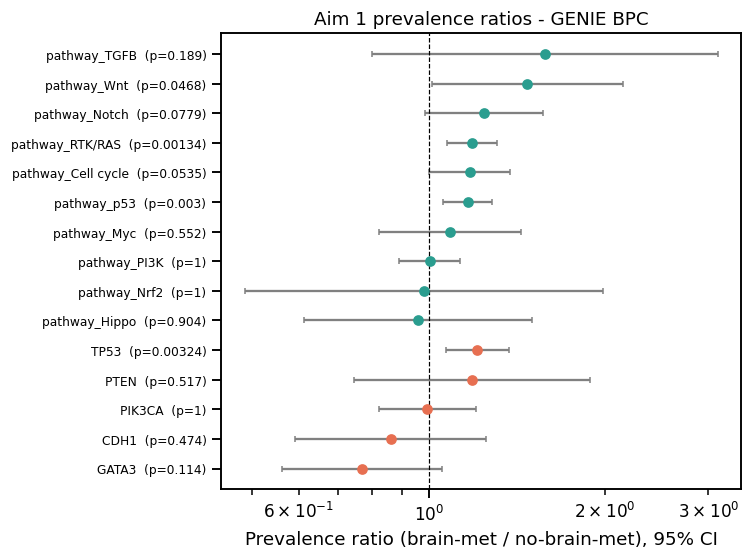

In [6]:
plot_df = res.dropna(subset=['prev_ratio']).copy().sort_values(['kind','prev_ratio'])
fig, ax = plt.subplots(figsize=(7, max(3, 0.35*len(plot_df))))
y = np.arange(len(plot_df))
colors = ['#e76f51' if k=='gene' else '#2a9d8f' for k in plot_df['kind']]
for i, (_, r) in enumerate(plot_df.iterrows()):
    ax.errorbar(r['prev_ratio'], i,
                xerr=[[r['prev_ratio']-r['pr_lo']], [r['pr_hi']-r['prev_ratio']]],
                fmt='o', color=colors[i], ecolor='grey', capsize=2)
ax.axvline(1, color='black', linestyle='--', linewidth=0.8)
labels = [f"{r['feature']}  (p={r['fisher_p']:.3g})" for _, r in plot_df.iterrows()]
ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=8)
ax.set_xscale('log'); ax.set_xlabel('Prevalence ratio (brain-met / no-brain-met), 95% CI')
ax.set_title('Aim 1 prevalence ratios - GENIE BPC')
plt.tight_layout()
plt.savefig(FIG / 'aim1_forest.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Oncoprint of top-5 split by `any_brain_met`

Identical shape to `src/modeling/aim1_gene_pathway.py` oncoprint output: red strip on top encodes brain-met status, grey matrix encodes per-gene mutation status, samples sorted by brain-met then by gene status.

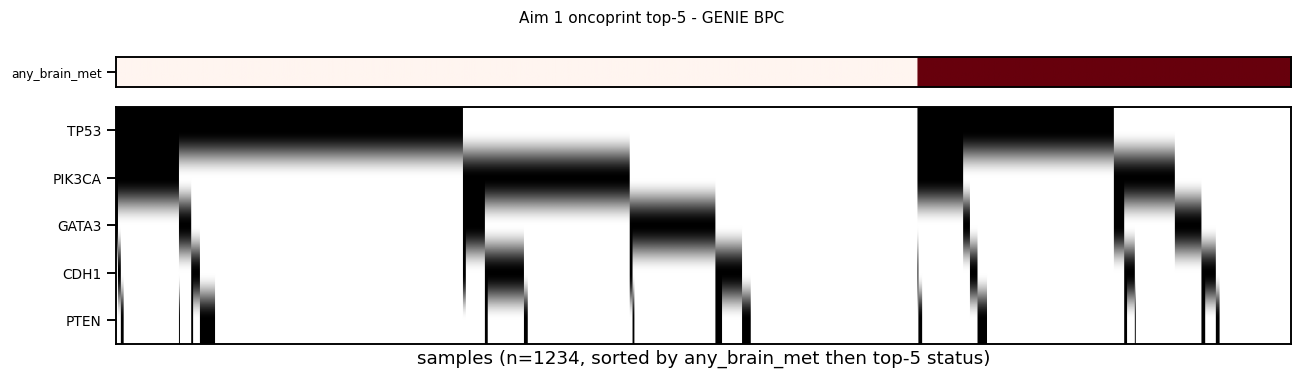

In [7]:
gene_cols = [g for g in top5 if g in df.columns]
sub = df[gene_cols + ['any_brain_met']].dropna(subset=['any_brain_met']).copy()
sub['any_brain_met'] = sub['any_brain_met'].astype(int)
sub = sub.sort_values(['any_brain_met'] + gene_cols,
                      ascending=[True] + [False]*len(gene_cols))
mat = sub[gene_cols].fillna(0).astype(int).values.T
fig, (ax_top, ax) = plt.subplots(2, 1, figsize=(12, max(2.5, 0.4*len(gene_cols)+1.5)),
                                 gridspec_kw={'height_ratios':[0.5,4]}, sharex=True)
ax_top.imshow(sub['any_brain_met'].values.reshape(1,-1), aspect='auto', cmap='Reds', vmin=0, vmax=1)
ax_top.set_yticks([0]); ax_top.set_yticklabels(['any_brain_met'], fontsize=8); ax_top.set_xticks([])
ax.imshow(mat, aspect='auto', cmap='Greys', vmin=0, vmax=1)
ax.set_yticks(range(len(gene_cols))); ax.set_yticklabels(gene_cols, fontsize=9)
ax.set_xlabel(f'samples (n={len(sub)}, sorted by any_brain_met then top-5 status)'); ax.set_xticks([])
fig.suptitle('Aim 1 oncoprint top-5 - GENIE BPC', fontsize=10)
plt.tight_layout()
plt.savefig(FIG / 'aim1_oncoprint.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Table 1 - demographics and clinical characteristics by `any_brain_met`

Continuous: median (Q1-Q3) + mean (SD). Categorical: n (col %).

In [8]:
cont_vars = ['age_dx_num', 'mutation_count_all_sites_sum', 't_alt_count_max', 'OS_months', 'tt_brain_met_mos']
cat_vars  = ['receptor_primary_cat', 'stage_diag_group', 'stage_iv_bin', 'grade_ord',
             'race_clean', 'ethnicity_clean', 'sample_type_bin', 'SEQ_ASSAY_ID',
             'her2_status_bin', 'met_loc']

def summarise(df, group_col='any_brain_met'):
    rows = []
    for v in cont_vars:
        if v not in df.columns: continue
        for g, sub in df.groupby(group_col):
            s = pd.to_numeric(sub[v], errors='coerce').dropna()
            rows.append(dict(variable=v, level=None, group=int(g) if pd.notna(g) else g,
                             n=len(s), median=s.median(), q1=s.quantile(0.25), q3=s.quantile(0.75),
                             mean=s.mean(), sd=s.std()))
    for v in cat_vars:
        if v not in df.columns: continue
        tab = pd.crosstab(df[v], df[group_col], dropna=False)
        col_tot = tab.sum(axis=0)
        for lvl, row in tab.iterrows():
            for g in row.index:
                rows.append(dict(variable=v, level=str(lvl), group=int(g) if pd.notna(g) else g,
                                 n=int(row[g]), pct=row[g]/col_tot[g] if col_tot[g] else np.nan))
    return pd.DataFrame(rows)

table1 = summarise(df)
table1.to_csv(OUT / 'aim1_table1_by_brain_met.csv', index=False)
table1.head(25)

,variable,level,group,n,median,q1,q3,mean,sd,pct
0,age_dx_num,None,0,841,45.000000,39.000000,49.000000,43.472057,7.253045,NaN
1,age_dx_num,None,1,393,42.000000,37.000000,47.000000,41.768448,7.387581,NaN
2,mutation_count_all_sites_sum,None,0,841,5.000000,3.000000,7.000000,5.411415,3.728215,NaN
3,mutation_count_all_sites_sum,None,1,393,5.000000,3.000000,8.000000,6.050891,5.007897,NaN
4,t_alt_count_max,None,0,823,201.000000,115.000000,338.000000,273.942892,308.659208,NaN
5,t_alt_count_max,None,1,379,215.000000,123.000000,369.000000,320.664908,578.882358,NaN
6,OS_months,None,0,841,51.348684,35.296053,82.861842,65.721572,47.932338,NaN
7,OS_months,None,1,393,63.717105,37.631579,98.881579,74.158882,50.648461,NaN
8,tt_brain_met_mos,None,0,841,51.348684,35.296053,82.861842,65.721572,47.932338,NaN
9,tt_brain_met_mos,None,1,393,39.177632,22.072368,71.546053,52.493806,45.398516,NaN


## 7. Descriptive plots translated from `plots_descriptive.R`

Original R script grouped on DFS; the brain-met project's analogue is `any_brain_met`. Plot families preserved:

1. Variant / mutation count histogram + boxplots overall and by outcome.
2. P(brain met) across demographics (race, ethnicity, receptor subtype).
3. Gene mutation prevalence segment plots, side by side for brain-met vs no-brain-met.
4. Stacked bar of brain-met share by receptor subtype.
5. Top-genes-by-subtype grid (from `src/data reports/export and generate genetic mut prevalence plots.py`).

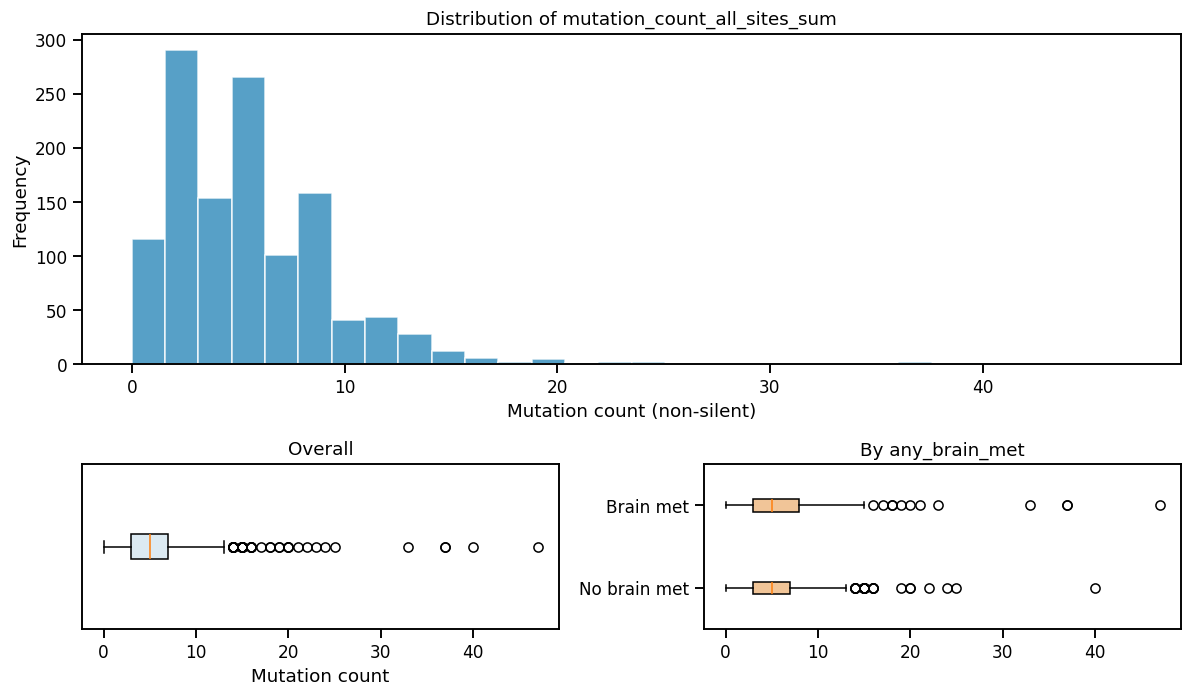

In [9]:
# 7.1 - mutation count panel (analog of R variant_allele_count layout)
mc = pd.to_numeric(df['mutation_count_all_sites_sum'], errors='coerce')
fig = plt.figure(figsize=(11, 6.5))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])
top = fig.add_subplot(gs[0, :])
top.hist(mc.dropna(), bins=30, color='#3a8fbe', alpha=0.85, edgecolor='white')
top.set_xlabel('Mutation count (non-silent)'); top.set_ylabel('Frequency')
top.set_title('Distribution of mutation_count_all_sites_sum')
axL = fig.add_subplot(gs[1, 0])
axL.boxplot(mc.dropna(), vert=False, patch_artist=True, boxprops=dict(facecolor='#dceaf2'))
axL.set_xlabel('Mutation count'); axL.set_title('Overall'); axL.set_yticks([])
axR = fig.add_subplot(gs[1, 1])
by = [pd.to_numeric(df.loc[df['any_brain_met']==g, 'mutation_count_all_sites_sum'], errors='coerce').dropna()
      for g in [0, 1]]
axR.boxplot(by, vert=False, patch_artist=True, boxprops=dict(facecolor='#f1c598'))
axR.set_yticklabels(['No brain met', 'Brain met']); axR.set_title('By any_brain_met')
plt.tight_layout()
plt.savefig(FIG / 'aim1_mutation_count_hist_box.png', dpi=300, bbox_inches='tight')
plt.show()

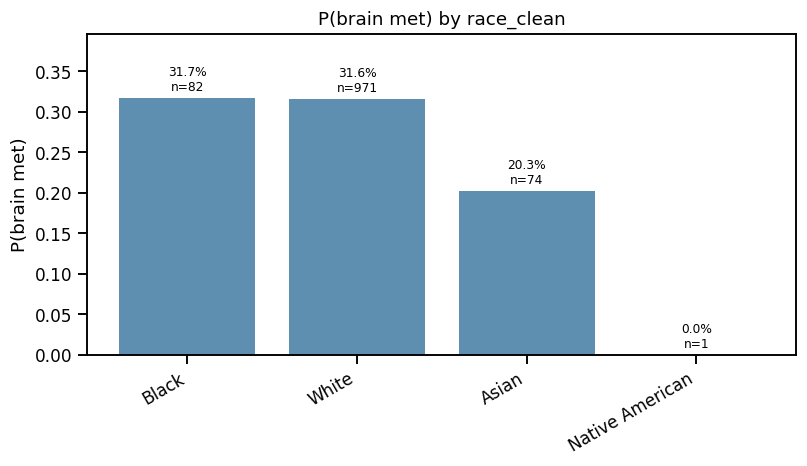

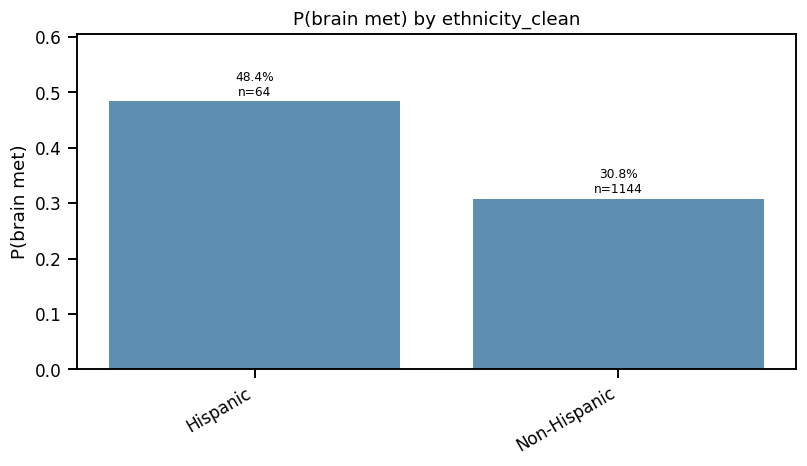

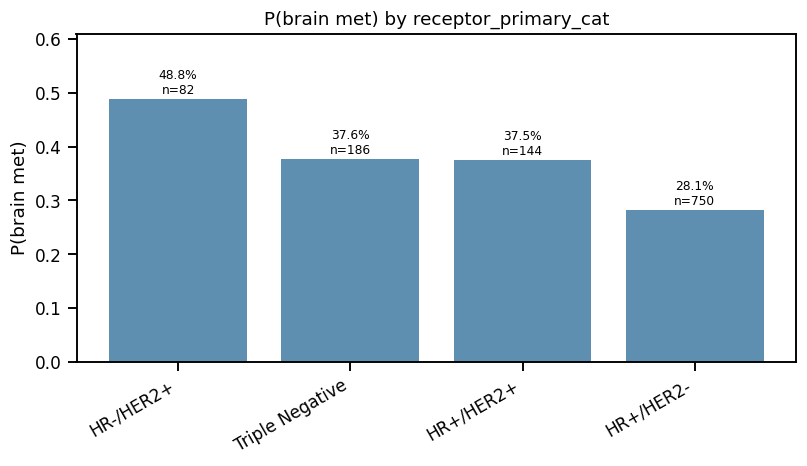

In [10]:
# 7.2 - P(brain met) by demographics
def plot_prop_by_group(df, group_col, out_name, ylab='P(brain met)'):
    g = (df.groupby(group_col)['any_brain_met']
           .agg(['size','mean']).rename(columns={'size':'n','mean':'p'})
           .sort_values('p', ascending=False))
    fig, ax = plt.subplots(figsize=(7.5, 4.4))
    ax.bar(g.index.astype(str), g['p'], color='#5e8fb0')
    for i, (_, row) in enumerate(g.iterrows()):
        ax.text(i, row['p']+0.005, f'{row["p"]*100:.1f}%\nn={int(row["n"])}',
                ha='center', va='bottom', fontsize=8)
    ax.set_ylabel(ylab); ax.set_title(f'{ylab} by {group_col}')
    ax.set_ylim(0, g['p'].max()*1.25)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(FIG / out_name, dpi=300, bbox_inches='tight')
    plt.show()

for col, name in [('race_clean', 'aim1_p_brain_met_by_race.png'),
                  ('ethnicity_clean', 'aim1_p_brain_met_by_ethnicity.png'),
                  ('receptor_primary_cat', 'aim1_p_brain_met_by_subtype.png')]:
    if col in df.columns:
        plot_prop_by_group(df.dropna(subset=[col]), col, name)

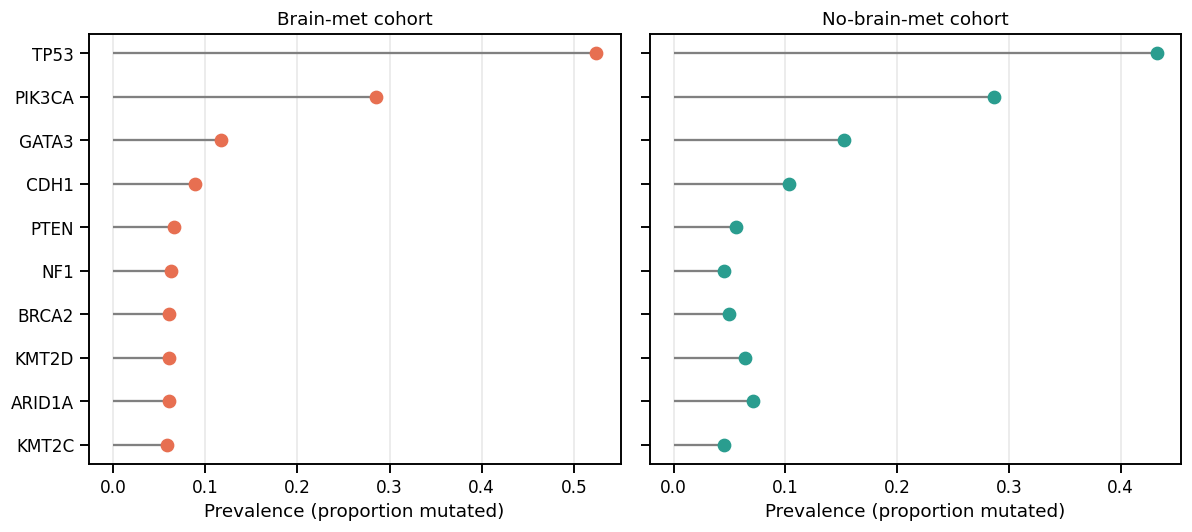

In [11]:
# 7.3 - Side-by-side segment plots: gene prevalence in brain-met vs no-brain-met (top-10)
def prev_topN(df, mask, N=10):
    cols_present = [g for g in top10 if g in df.columns]
    sub = df[mask]
    counts = sub[cols_present].sum().sort_values(ascending=True)
    return counts / len(sub)

prev_bm  = prev_topN(df, df['any_brain_met']==1)
prev_nbm = prev_topN(df, df['any_brain_met']==0)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for ax, ser, title, color in [(axes[0], prev_bm,  'Brain-met cohort',     '#e76f51'),
                              (axes[1], prev_nbm, 'No-brain-met cohort', '#2a9d8f')]:
    ax.hlines(ser.index, 0, ser.values, color='grey')
    ax.plot(ser.values, ser.index, 'o', color=color, markersize=8)
    ax.set_xlabel('Prevalence (proportion mutated)')
    ax.set_title(title); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / 'aim1_top10_prevalence_segment.png', dpi=300, bbox_inches='tight')
plt.show()

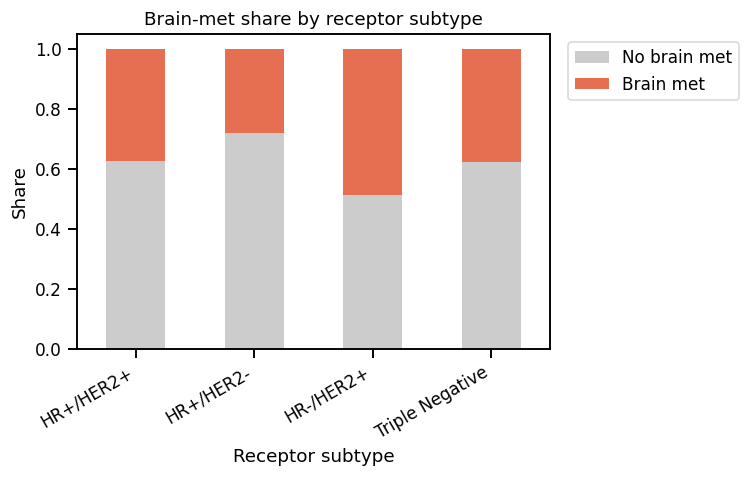

In [12]:
# 7.4 - Stacked share of any_brain_met by receptor subtype
if 'receptor_primary_cat' in df.columns:
    ct = (pd.crosstab(df['receptor_primary_cat'], df['any_brain_met'], normalize='index')
             .rename(columns={0:'No brain met', 1:'Brain met'}))
    ax = ct.plot(kind='bar', stacked=True, figsize=(7, 4.5),
                 color=['#cccccc','#e76f51'])
    ax.set_ylabel('Share'); ax.set_xlabel('Receptor subtype'); ax.set_title('Brain-met share by receptor subtype')
    ax.legend(title='', bbox_to_anchor=(1.02,1), loc='upper left')
    plt.xticks(rotation=30, ha='right'); plt.tight_layout()
    plt.savefig(FIG / 'aim1_brain_met_share_by_subtype.png', dpi=300, bbox_inches='tight')
    plt.show()

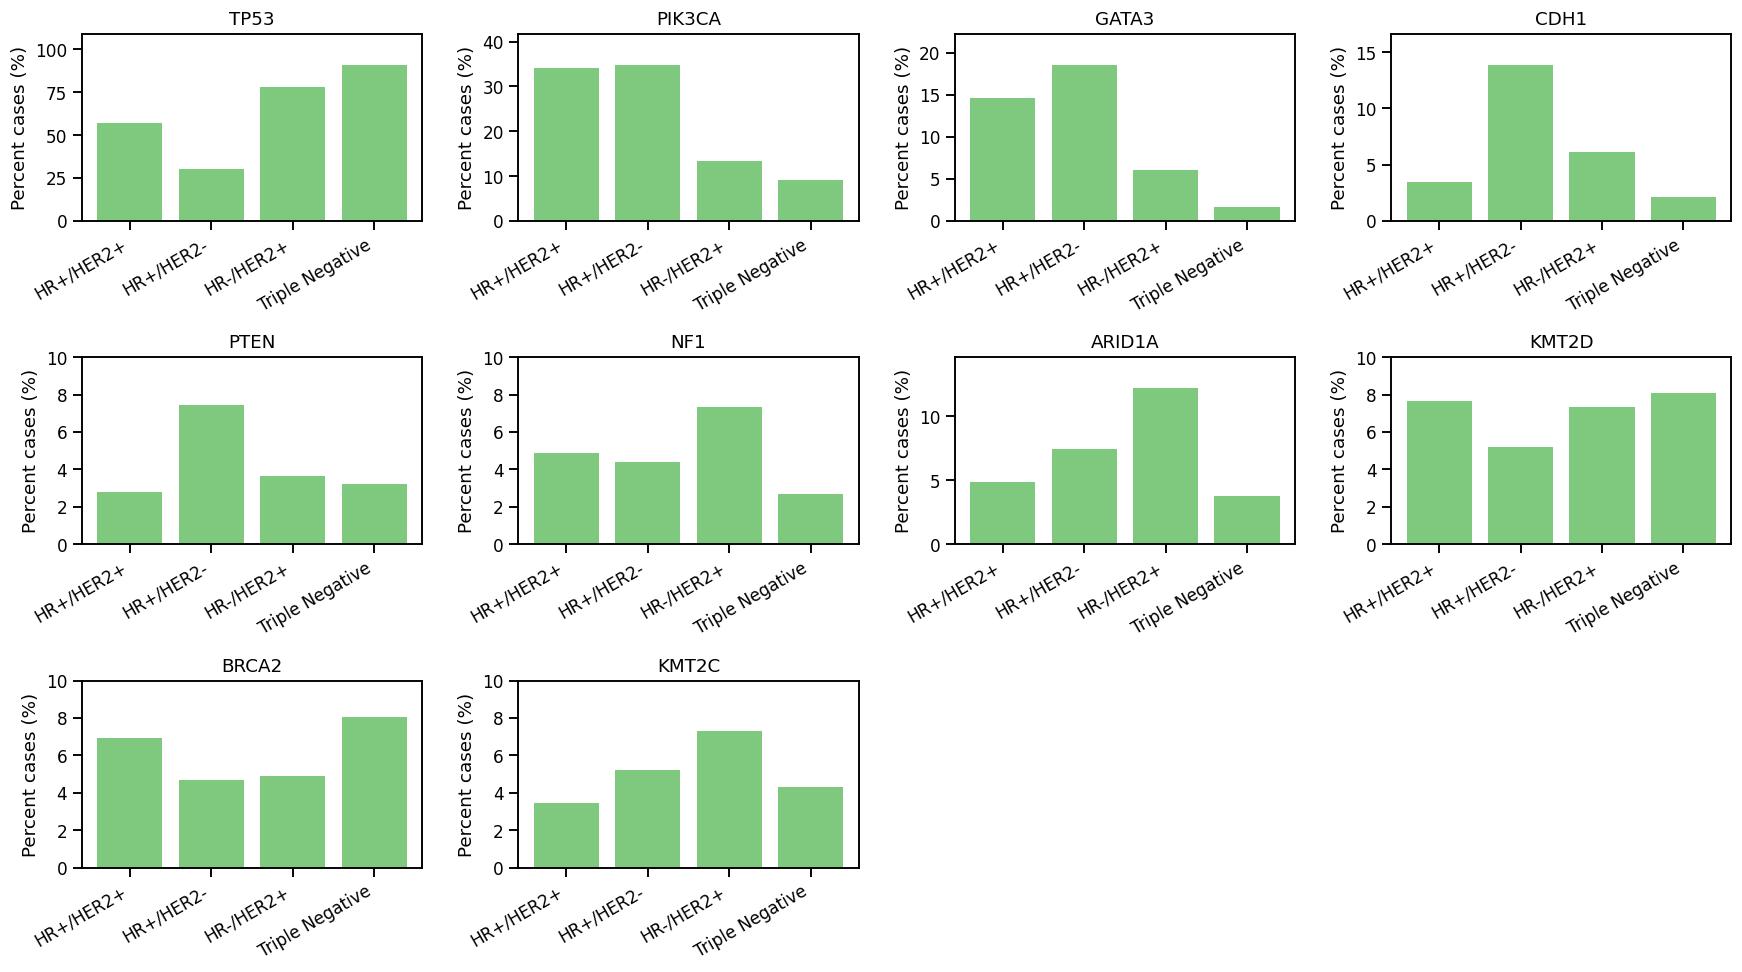

In [13]:
# 7.5 - Top-genes-by-subtype grid (from src/data reports/export and generate genetic mut prevalence plots.py)
def per_subtype_grid(df, top_genes, subtype_col='receptor_primary_cat', out_name='aim1_top_genes_by_subtype.png'):
    cols = [g for g in top_genes if g in df.columns]
    groups = sorted(df[subtype_col].dropna().astype(str).unique())
    ncols = 4
    nrows = (len(cols) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), squeeze=False)
    for idx, gene in enumerate(cols):
        ax = axes[idx//ncols][idx%ncols]
        vals = []
        for g in groups:
            m = df[subtype_col].astype(str) == g
            vals.append((df.loc[m, gene].sum() / max(m.sum(),1)) * 100)
        ax.bar(groups, vals, color='#7fc97f')
        ax.set_title(gene); ax.set_ylim(0, max(10, max(vals)*1.2))
        ax.set_ylabel('Percent cases (%)')
        plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
    for idx in range(len(cols), nrows*ncols):
        axes[idx//ncols][idx%ncols].axis('off')
    plt.tight_layout()
    plt.savefig(FIG / out_name, dpi=300, bbox_inches='tight')
    plt.show()

per_subtype_grid(df, top10)

## 8. Optional - multi-cohort loop

`src/modeling/_lib.py` exposes `COHORTS = {'genie','tcga','msk18'}`. Enable the cell below to repeat Aim 1 across the harmonised TCGA and MSK 2018 frames.

In [14]:
RUN_MULTI_COHORT = False  # set True after harmonised TCGA / MSK18 frames are on disk

if RUN_MULTI_COHORT:
    for c in ['tcga', 'msk18']:
        try:
            dc = L.load_cohort(c)
            t5 = L.load_top_genes(c, n=5)
            print(f'\n=== {c.upper()}  n={len(dc)}  any_brain_met={int(dc["any_brain_met"].sum())}  top5={t5} ===')
            rows_c = []
            for g in t5:
                if g in dc.columns:
                    rows_c.append(dict(kind='gene', **two_by_two(dc, g)))
            for p in PATHWAY_COLS:
                if p in dc.columns:
                    rows_c.append(dict(kind='pathway', **two_by_two(dc, p)))
            res_c = pd.DataFrame(rows_c)
            for k in res_c['kind'].unique():
                m = res_c['kind']==k
                ps = res_c.loc[m,'fisher_p'].fillna(1.0).values
                res_c.loc[m,'p_holm'] = multipletests(ps, method='holm')[1]
                res_c.loc[m,'p_bh']   = multipletests(ps, method='fdr_bh')[1]
            out_c = OUT / f'aim1_gene_pathway_comparison_{c}.csv'
            res_c.to_csv(out_c, index=False)
            print(f'  wrote {out_c}')
        except FileNotFoundError as e:
            print(f'  SKIP {c}: {e}')

## 9. Deliverables

| File | README mapping |
|---|---|
| `data/interim/aim1/aim1_cohort_sizes.csv` | Section 4 |
| `data/interim/aim1/aim1_gene_pathway_comparison.csv` | Section 7 + Section 12 rows 1-2 |
| `data/interim/aim1/aim1_table1_by_brain_met.csv` | manuscript Table 1 |
| `manuscript components/figures/aim1/aim1_forest.png` | Section 12 |
| `manuscript components/figures/aim1/aim1_oncoprint.png` | Section 12 row 3 |
| `manuscript components/figures/aim1/aim1_mutation_count_hist_box.png`, `aim1_p_brain_met_by_*.png`, `aim1_top10_prevalence_segment.png`, `aim1_brain_met_share_by_subtype.png`, `aim1_top_genes_by_subtype.png` | descriptive plots translated from `plots_descriptive.R` + `export and generate genetic mut prevalence plots.py` |